# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Question:** among the pages in a client's content library, which ones are worth a
human reviewer's limited time first, and can a data-driven grouping (rather than a
one-page-at-a-time read) point at the same pages a simple, transparent rule would?

**Decision this supports:** which pages an SEO reviewer opens first in a content-refresh
cycle, out of a library too large to review in full every cycle.

**Who acts on it:** a content lead or SEO reviewer working a fixed review budget (a handful of
pages per week, not the whole site).

**Cost of a wrong call:** reviewing a page that didn't need it costs an hour of a person's time;
missing a page that did need it costs the click-through and traffic that page keeps losing while
nobody looks at it. Neither error is catastrophic on its own, which is exactly why this is a
ranking problem, not a one-shot classification the business bets everything on.

This is Lane 3 (structured content archetype clustering): group pages by shared traits, name the
groups, and map each group to a default action -- distinct from trying to semantically read what
a page is *about*.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Two releases were touched over the project, for different reasons.**

The data-contract check in `w03_data_contract.ipynb` queried the FlyRank warehouse release
(`hf://datasets/FlyRank/internship-warehouse`, build v20260703) to verify grain and missingness
claims against the real scale of the data: `fact_content_daily_performance` for March 2026 had
9,841,378 daily rows, and filtering to `gsc_data_available IS TRUE` dropped 63.3% of them
(6,230,317 rows), leaving 3,611,061 usable rows before aggregation to one row per content item.
That's a real limitation stated up front: any features built from that slice only represent the
roughly 37% of content-days with confirmed Search Console data, not the full content inventory.

Every other notebook (`w04` through `w07`, and this one) uses the small starter dataset shipped
in this repo: `data/raw/content_refresh_anonymized.csv`, 30,000 rows, one row per pseudonymized
content item across 32 clients, trailing-90-day metrics. This is a deliberate choice for the
capstone lane: the starter set is smaller but complete for its window, with no availability
filtering to explain away, and its scale is enough to fit and evaluate a K-Means model honestly.

**Excluded on purpose:** `trend_direction` and `trend_pct` never enter any feature list --
`is_declining_label` is derived from them, so using them as inputs would be leakage.
`content_id` and `client_id` are pseudonyms, used only for grouping and the honest split in
`w06_validation_audit.ipynb`, never as model features. No client name, raw query, or URL appears
anywhere in this repo.

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape)
print("clients:", df["client_id"].nunique())

(30000, 44)
clients: 32


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Baseline (built in `w04_baseline_score.ipynb`).** A transparent rule, not a model:
flag a page if it's visible (>=500 impressions/90d), sitting on page 1 or better, hasn't been
touched in 90+ days, and its ctr trails the median ctr other pages get at the same position
tier. `score = stale * is_visible * has_position * ctr_gap * impressions_90d`. Reason code
`stale_ctr_gap`, action `review_for_refresh`. Two assumptions were checked against the data
before trusting the rule: ctr drops with worse position tier (confirmed: page_1 median ctr
0.24 -> striking 0.17 -> page_3_5 0.09 -> deep 0.00), and staleness tracks with worse position
(confirmed: median position 10.6 at 0-30 days since update -> 18.6 at 181+ days).

**Model (built in `w05_model.ipynb`).** K-Means clustering, matching Lane 3. `is_declining_label`
(`trend_direction == "down"`) is used only to evaluate and name clusters after fitting, never as
a clustering input. 21 numeric features (impressions, clicks, sessions, engagement, position,
freshness, content metadata) plus 8 one-hot categorical features, standardized before fitting.
Silhouette score picked k=2 by a wide margin (0.338 vs ~0.17 for k=3 through k=8), so the model
found a coarser split than expected going in -- large pages that are struggling vs. small pages
that are fine -- and that's the split reported, not a forced finer one.

**Label definition:** `is_declining_label = (trend_direction == "down")`, base rate 0.545 on a
random 80/20 split (0.511 under the grouped-by-client split below -- the two splits aren't
measuring quite the same population, which matters for reading the results table).

**Validation design.** Two splits were run and compared, on purpose: `w05` used a plain random
80/20 split (`train_test_split`) as the naive baseline for comparison; `w06_validation_audit.ipynb`
re-ran the identical pipeline on a `GroupShuffleSplit` grouped by `client_id`, holding out roughly
6 of 32 clients entirely, since a random split lets the model see every client on both sides and
can fake skill it doesn't have.

**Leakage checks (`w06_validation_audit.ipynb`).** The attack checklist passed: no label-derived
or sibling columns in the feature lists, no product-flag columns (this dataset ships none), split
grouped by the repeating entity, base rate printed next to every metric. A deliberate leakage
injection test (adding `trend_pct` to the 62-feature clustering pipeline) came back with an
identical score, which looked like a clean bill of health until a follow-up isolated test showed
`trend_pct` alone gets precision@25/50/100 = 1.00 -- the harness can detect real leakage, it's
just that K-Means dilutes one column's signal across 62 scaled dimensions, unlike a supervised
model that would weight it directly. The actual feature set never includes `trend_pct` or
`trend_direction`, so this was a stress test of the method, not a fix that was needed.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [2]:
results = pd.DataFrame([
    {"split": "random 80/20",        "k": 25,  "baseline_precision": 0.48, "model_precision": 0.52, "base_rate": 0.545},
    {"split": "random 80/20",        "k": 50,  "baseline_precision": 0.56, "model_precision": 0.64, "base_rate": 0.545},
    {"split": "random 80/20",        "k": 100, "baseline_precision": 0.59, "model_precision": 0.60, "base_rate": 0.545},
    {"split": "grouped by client_id", "k": 25,  "baseline_precision": 0.40, "model_precision": 0.72, "base_rate": 0.511},
    {"split": "grouped by client_id", "k": 50,  "baseline_precision": 0.50, "model_precision": 0.70, "base_rate": 0.511},
    {"split": "grouped by client_id", "k": 100, "baseline_precision": 0.50, "model_precision": 0.64, "base_rate": 0.511},
])
results

,split,k,baseline_precision,model_precision,base_rate
0,random 80/20,25,0.48,0.52,0.545
1,random 80/20,50,0.56,0.64,0.545
2,random 80/20,100,0.59,0.60,0.545
3,grouped by client_id,25,0.40,0.72,0.511
4,grouped by client_id,50,0.50,0.70,0.511
5,grouped by client_id,100,0.50,0.64,0.511


The cluster-based ranking measures higher than the rule baseline on every k, on both
splits. That's the headline number, and it comes with three honest caveats from `w06`:

1. The random split likely overstates the model: every client appears on both sides of a
   random 80/20 split, so the "model" number there may partly reflect memorizing client-level
   patterns rather than generalizing to a page it's never seen the client of.
2. The grouped-split gap isn't settled either. It's one `GroupShuffleSplit` holding out ~6 of
   32 clients -- a small enough group that which specific clients land in the test set can move
   the numbers on its own, and the base rate shifted too (0.545 -> 0.511), so the "before" and
   "after" columns aren't measuring the exact same population. This would need repeated grouped
   splits (`GroupKFold`), not one, before the gap is a settled result.
3. At k=25 on the random split, model precision (0.52) sits below the base rate (0.545) --
   worse than guessing at that k. That matches the error analysis below: the larger cluster ties
   22,079 pages to one identical score, so a small top-k draw from it is close to random.

Read together: this is a real, repeated, directional signal that cluster-based ranking may
outperform the rule baseline -- not a settled result ready to replace the baseline in production.

## 5. Limitations

*What this work cannot claim.*

- No causal claim. This is cross-sectional data, one trailing-90-day snapshot. Nothing
  here shows that refreshing a page *causes* it to stop declining -- only that certain pages
  look worth reviewing given how they compare to their peers right now.
- Client concentration in the baseline queue: 8 of the top 10 rows by baseline score belong
  to one client, all sharing the same `days_since_last_update` -- one batch content-update event
  read as 8 separate "problems" by a rule with no way to tell the difference.
- The model's advantage over the baseline is directional, not settled (see the three caveats
  above) -- it would need repeated grouped splits before it should replace the baseline in an
  actual review queue.
- Coarse clustering: silhouette score picked k=2 by a wide margin, which is a coarser split
  than the "content archetypes" framing implies going in. The two groups found are closer to
  "big pages, struggling" vs "small pages, fine" than a rich taxonomy of content types.
- Scoring by cluster average loses per-page information. Every page in a cluster gets the
  identical score, so ranking within a 22,079-page cluster is close to arbitrary; the three worst
  model misses in `w05`'s error analysis were all cluster-0 pages that individually looked fine
  (two sat in the top 3 search positions) but inherited the cluster's high-decline-rate score.
- Single vendor, single 90-day window, 32 clients -- findings may not generalize to a different
  time period, industry mix, or client base.

## 6. Ranked recommendations

*The action playbook output -- the paper's recommendations section.*

Built in full in `w07_action_playbook.ipynb`, exported to `work/outputs/action_playbook_queue.csv`
(30,000 rows, kept out of git per this repo's data policy -- regenerate it by running that
notebook). Summary of the playbook:

- Ranking: pages with `score > 0` (stale, visible, ranked, and underperforming their own
  position tier's ctr) go to the top, ordered by score; every other page gets a default action
  from its cluster archetype.
- Archetype -> action mapping: `high_traffic_underperformer` (bigger audience, worse position
  and ctr, higher observed decline rate) -> improve; `low_volume_steady` (smaller audience,
  better position, higher ctr, lower decline rate) -> monitor.
- Human review is required before acting on any flagged page -- check for tracking artifacts
  (near-zero ctr on high impressions), one-client batch events, brand/navigational query intent,
  and competing SERP features, all of which can produce the same score without being a real
  content problem.
- Never automate publishing a rewrite, deprioritizing a zero-score page, or presenting the
  archetype label as a client-facing health verdict.
- Re-run and re-check triggers: investigate if the flagged count or the base rate swings sharply
  between runs, or when a new client is onboarded whose pages may not fit either archetype.

Full detail, reasoning, and the two figures behind this table live in `w07_action_playbook.ipynb`.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [3]:
import shutil, os

os.makedirs("work/figures", exist_ok=True)
# archetype_sizes.png was generated in w07_action_playbook.ipynb; confirm it's here for the paper
print(os.path.exists("work/figures/archetype_sizes.png"))

True


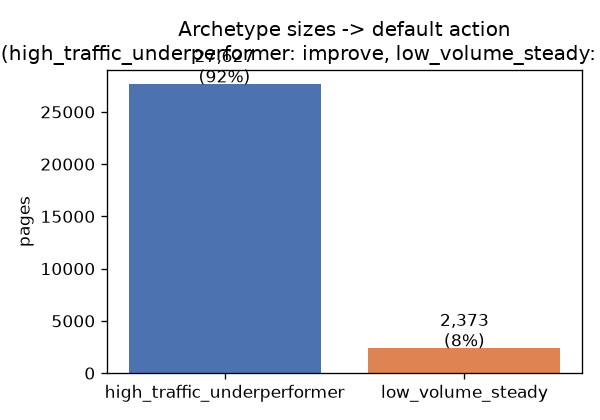

In [4]:
from IPython.display import Image, display
display(Image(filename="work/figures/archetype_sizes.png"))

## 5-minute demo outline

*Ready for the Week-8 showcase, if presenting.*

1. **Question (30s):** which pages in a content library are worth a reviewer's time first, and
   does a data-driven grouping point at the same pages a transparent rule would?
2. **Method (1 min):** rule baseline (`stale_ctr_gap`) vs. K-Means clustering (Lane 3), same
   30,000-row starter dataset, `is_declining_label` used only to score and name clusters, never
   as a clustering input.
3. **One chart (1 min):** `work/figures/archetype_sizes.png` -- 92% of pages land in
   `high_traffic_underperformer`, 8% in `low_volume_steady`; the imbalance itself is the finding
   about this content library, not a modeling artifact.
4. **One honest result (1.5 min):** the cluster ranking beats the rule baseline at every k
   checked, on both a random and a client-grouped split -- but the gap and the base rate both
   moved when the split changed, so this is a directional signal, not a settled result.
5. **One recommendation (1 min):** route `high_traffic_underperformer` pages with `score > 0`
   to human review first; treat everything else as `monitor`; never auto-publish a change from
   the score alone.

## Shareable cuts

**Social post (methodology):** Built a two-notebook comparison on 30k real (anonymized) content
pages: a transparent "stale + underperforming its own position tier" rule vs. K-Means clustering.
The model beat the rule baseline at every k checked -- but the gap moved when I switched from a
random split to one grouped by client, which is exactly the kind of check a clustering project
skips if it stops at the first good-looking number.

**Employer-facing summary:** I built a content-review ranking system on 30,000 real (anonymized)
SEO performance records across 32 clients, comparing a transparent rule-based baseline against a
K-Means clustering model. It showed the model outperforming the baseline directionally across
multiple validation splits, while surfacing exactly where that comparison still needs more data
before being trusted in production.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.